# MLFDR 中介效应模拟实验工作台

**R 语言 · 先生成文件，再读取实验 · 可扩展方法接口**

本 notebook 是项目的主入口。使用 **R / IRkernel**，依次执行即可生成数据文件、读取数据、比较 HDMT / MDACT / MLFDR，并在本文档中显示真实运行的表格和图形。交付版本保留执行输出；默认采用缩小的演示网格，结果不要求与论文完全一致。

依据：Roy & Zhang (2026), *Powerful large scale inference in high dimensional mediation analysis*, [PLOS Computational Biology](https://doi.org/10.1371/journal.pcbi.1013880)，第 2.2 节、式 (3)–(5)、图 2–4；用户提供的 `MLFDR.pdf` 和 `../MLFDR-main`。详细差异见后文及 `docs/SIMULATION_DESIGN.md`。

**运行顺序**：① 在下方调整参数 → ② 生成并保存全部数据 → ③ 从文件重新读取 → ④ 运行方法与汇总 → ⑤ 查看结果与扩展方法。所有 R 功能在 `R/` 中，notebook 负责控制参数和组织说明。已有文件通过内容标识复用；修改数据生成参数会进入新的数据目录。

In [1]:
# 1. 定位工程并检查已安装的 R 包，不自动安装或改动原始源码。
find_project_root <- function(start = getwd()) {
  path <- normalizePath(start, winslash = "/", mustWork = TRUE)
  for (i in 1:6) {
    if (file.exists(file.path(path, "R", "bootstrap.R"))) return(path)
    candidate <- file.path(path, "mlfdr_simulation_lab")
    if (file.exists(file.path(candidate, "R", "bootstrap.R"))) return(candidate)
    path <- dirname(path)
  }
  stop("请从工程根目录或 notebooks 目录启动 Jupyter。")
}
PROJECT_ROOT <- find_project_root()
source(file.path(PROJECT_ROOT, "R", "bootstrap.R"), encoding = "UTF-8")
options(repr.plot.width = 9, repr.plot.height = 6, repr.plot.res = 140,
        repr.matrix.max.rows = 30, repr.matrix.max.cols = 15)
check_dependencies()

# 2. 参数控制区：改完后从数据生成单元继续执行。
# 可选预设：demo / paper_grid / source_demo。
config <- default_config("demo")
config$seed <- 20261004L
config$m <- 1000L
config$n <- c(100L, 300L)
config$tau <- c(0.1, 1.0, 1.9)
config$repetitions <- 5L
config$scenarios <- c("linear", "confounded", "binary")
config$mixtures <- list(
  sparse = c(H00 = 0.88, H10 = 0.05, H01 = 0.05, H11 = 0.02),
  dense  = c(H00 = 0.40, H10 = 0.20, H01 = 0.20, H11 = 0.20)
)
config$dgp_profile <- "paper2026"  # 或 source_code，差异详见下文
config$exposure_probability <- 0.1
config$alpha_mean_scale <- 0.05
config$beta_mean_scale <- -0.5
config$alpha_noise_variance <- 1
config$beta_noise_variance <- 4
config$direct_mean <- 1
config$direct_sd <- sqrt(0.5)
config$error_sd_m <- 1
config$error_sd_y <- 1
config$confounder_max <- 0.5
config$q <- 0.05
config$methods <- c("HDMT", "MDACT", "MLFDR")
config$method_options <- list(
  HDMT = list(exact = 0L),
  MDACT = list(),
  MLFDR = list(eps = 0.01, twostep = FALSE, verbose = FALSE)
)
config$workers <- 2L              # Windows 使用 PSOCK；设为 1 可串行调试
config$export_first_long_csv <- TRUE

# 小规模源码设定对照：6 份数据，各条件1次，仅展示DGP差异，不作稳定排名。
RUN_SOURCE_CHECK <- TRUE
source_check_config <- default_config("source_demo")
source_check_config$m <- config$m
source_check_config$n <- max(config$n)
source_check_config$tau <- max(config$tau)
source_check_config$repetitions <- 1L
source_check_config$scenarios <- config$scenarios
source_check_config$mixtures <- config$mixtures
source_check_config$methods <- config$methods
source_check_config$q <- config$q
source_check_config$method_options <- config$method_options
source_check_config$workers <- config$workers
source_check_config$export_first_long_csv <- FALSE
validate_config(config)
design_overview(config)
estimate_storage(config)         # 保存前先了解数据量；估计值为未压缩矩阵大小

,package,version
,<chr>,<chr>
HDMT,HDMT,1.0.5
MLFDR,MLFDR,0.1.0
NMOF,NMOF,2.11.0
ggplot2,ggplot2,4.0.3
IRkernel,IRkernel,1.3.2


scenario,mixture,n,tau,m,repetitions,profile
<chr>,<chr>,<int>,<dbl>,<int>,<int>,<chr>
linear,sparse,100,0.1,1000,5,paper2026
confounded,sparse,100,0.1,1000,5,paper2026
binary,sparse,100,0.1,1000,5,paper2026
linear,dense,100,0.1,1000,5,paper2026
confounded,dense,100,0.1,1000,5,paper2026
binary,dense,100,0.1,1000,5,paper2026
linear,sparse,300,0.1,1000,5,paper2026
confounded,sparse,300,0.1,1000,5,paper2026
binary,sparse,300,0.1,1000,5,paper2026


datasets,method_fits,raw_matrix_GiB
<int>,<int>,<dbl>
180,540,0.536


## 先生成可读取文件

下面的单元只生成/校验模拟数据，**尚不运行任何比较方法**。每个场景、混合比例、样本量、τ 和重复编号对应一个 RDS，包含原始观测与评估用真值。`manifest.csv` 是数据索引，`manifest.rds` 保存完整设计。另导出第一份数据的长表 CSV 和独立真值 CSV，便于其他语言读取。

默认 180 份数据，每份具有同一个 `X`，以及 `m` 个不同的 `M_i → Y_i` 路径。`Y` 是 **n × m 结局矩阵**；它不是所有中介共同解释同一个结局的多中介模型。数据文件中矩阵的行是样本，列是路径，与原作者脚本的存储方向相反，但对应相同的统计模型。

`force = FALSE` 保留已生成的同设计文件。种子按场景和重复编号固定，方法数量、执行顺序和并行数不改变数据。发生没有变异的 X 时明确报错，不悄悄重采样。

In [2]:
manifest_generated <- generate_data_files(config, PROJECT_ROOT, force = FALSE)
manifest_path <- file.path(manifest_generated$directory, "manifest.rds")
cat("数据目录：", manifest_generated$directory, "\n")
cat("后续读取入口：", manifest_path, "\n")
head(manifest_generated$design[, c("case_id", "scenario", "mixture", "n", "m", "tau", "replicate", "seed", "file")], 6)
if (RUN_SOURCE_CHECK) {
  source_manifest_generated <- generate_data_files(source_check_config, PROJECT_ROOT, force = FALSE)
  source_manifest_path <- file.path(source_manifest_generated$directory, "manifest.rds")
  cat("额外源码设定对照的数据入口：", source_manifest_path, "\n")
}

Data saved/checked: 1/180



Data saved/checked: 20/180



Data saved/checked: 40/180



Data saved/checked: 60/180



Data saved/checked: 80/180



...

后续读取入口： D:/A_Mediation_analysis/code/mlfdr_simulation_lab/data/data_6fdb451c6d0d/manifest.rds 


,case_id,scenario,mixture,n,m,tau,replicate,seed,file
,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<int>,<int>,<chr>
1,linear_sparse_n100_t01_r0001,linear,sparse,100,1000,0.1,1,143140741,linear_sparse_n100_t01_r0001.rds
2,confounded_sparse_n100_t01_r0001,confounded,sparse,100,1000,0.1,1,127326492,confounded_sparse_n100_t01_r0001.rds
3,binary_sparse_n100_t01_r0001,binary,sparse,100,1000,0.1,1,97036070,binary_sparse_n100_t01_r0001.rds
4,linear_dense_n100_t01_r0001,linear,dense,100,1000,0.1,1,28913323,linear_dense_n100_t01_r0001.rds
5,confounded_dense_n100_t01_r0001,confounded,dense,100,1000,0.1,1,260166805,confounded_dense_n100_t01_r0001.rds
6,binary_dense_n100_t01_r0001,binary,dense,100,1000,0.1,1,137814416,binary_dense_n100_t01_r0001.rds


Data saved/checked: 1/6



Data saved/checked: 6/6



额外源码设定对照的数据入口： D:/A_Mediation_analysis/code/mlfdr_simulation_lab/data/data_9aaefd4678b4/manifest.rds 


## Simulation 数据设计与参数含义

每条路径首先抽取潜在状态 $H_{00},H_{10},H_{01},H_{11}$，概率按照配置中的 **H00, H10, H01, H11** 顺序。前 3 类属于复合零假设 $H_{0i}:\alpha_i\beta_i=0$，只有 $H_{11}$ 为真正中介效应。类别是随机抽样，实际非零数不强制等于 `m × π11`。

默认 `paper2026` 遵循所提供 **2026 年发表版正文第 5 页**：

$$\alpha_i=\mathbf1_{H_{10}\cup H_{11}}(0.05\tau+h_i),\quad h_i\sim N(0,1/n),$$
$$\beta_i=\mathbf1_{H_{01}\cup H_{11}}(-0.5\tau+g_i),\quad g_i\sim N(0,4/n).$$

`alpha_noise_variance` 和 `beta_noise_variance` 是上式方差的分子；R 的 `rnorm` 需要标准差，因此分别使用 `sqrt(1/n)`、`sqrt(4/n)`。非零均值 `0.05τ`、`−0.5τ` **不另除以 √n**。暴露 $X_j\sim Bernoulli(0.1)$，直接效应 $\gamma_i\sim N(1,0.5)$ 按“第二参数为方差”解释，误差独立 $N(0,1)$。

| 场景 | 数据生成 | 拟合模型 |
|:--|:--|:--|
| `linear` | M = αX + e；Y = βM + γX + ε | `M ~ X`；`Y ~ M + X` |
| `confounded` | M、Y 分别增加 θZ、δZ；Z 为标准正态，θ、δ 独立均匀分布 U(0,0.5) | `M ~ X + Z`；`Y ~ M + X + Z` |
| `binary` | M 同线性；Y 为 Bernoulli，发生概率 = plogis(βM + γX) | M 使用 OLS；Y 使用 logistic GLM |

所有回归包含截距。线性回归使用与 `lm` 数值等价的矩阵计算；测试脚本逐项校验了估计系数、方差和 p 值。二元场景使用 `glm(..., family = binomial())` 的 Wald p 值。

### 论文正文与源码并不相同

作者 `linear_model.R` / `binY.R` 中的 `rnorm(m, mu1, kap)`、`rnorm(m, mu2, psi)` 取 `kap=1`、`psi=4`，代表 **标准差 1 和 4**，没有 `1/√n` 缩放；直接效应使用 `rnorm(1,0.5)`，代表均值 0.5、标准差 1。`source_demo` 预设完整切换到该解释。若只把 `dgp_profile` 改成 `source_code`，还需相应设置 `direct_mean=0.5, direct_sd=1` 才与源码的直接效应一致。

本演示只缩小 τ 网格与重复数，保留 m=1000、n=100/300 和三种基本场景。`paper_grid` 使用 τ=0.1,0.3,…,1.9、每条件 250 次（采用作者脚本的重复数），会生成 **30,000 份数据**，未压缩两大矩阵约 **89.4 GiB**，耗时取决于 EM。它不是“保证复现论文图”的预设。SVA、交互、复合备择、TCGA 实际数据不属于本次基础演示。

In [3]:
# 重新从磁盘读取，而不是直接把生成函数的返回对象送给实验。
manifest <- read_manifest(manifest_path)
example_id <- manifest$design$case_id[1]
example_data <- read_dataset(manifest, example_id, verify = TRUE)
cat("读取：", example_id, "\n")
cat("M / Y 维度：", paste(dim(example_data$M), collapse = " × "), "\n")
print(table(example_data$truth$state))
head(example_data$truth, 6)

# 展示跨语言可读的 CSV；真值在单独的 example_long_truth.csv。
example_csv <- file.path(manifest$directory, "example_long.csv")
head(read.csv(example_csv, nrows = 6), 6)

读取： linear_sparse_n100_t01_r0001 


M / Y 维度： 100 × 1000 



H00 H01 H10 H11 
874  64  39  23 


,pathway_id,state,alpha,beta,direct,theta,delta,is_nonnull
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
1,pathway_0001,H00,0,0,2.0536509,0,0,FALSE
2,pathway_0002,H00,0,0,1.1469982,0,0,FALSE
3,pathway_0003,H00,0,0,1.1123105,0,0,FALSE
4,pathway_0004,H00,0,0,-0.4714209,0,0,FALSE
5,pathway_0005,H00,0,0,1.9239298,0,0,FALSE
6,pathway_0006,H00,0,0,1.9031692,0,0,FALSE


,subject_id,pathway_id,X,Z,M,Y
,<int>,<chr>,<int>,<lgl>,<dbl>,<dbl>
1,1,pathway_0001,0,NA,-0.08564485,1.46575942
2,2,pathway_0001,0,NA,-0.40062243,0.14800249
3,3,pathway_0001,0,NA,1.12978613,0.32289124
4,4,pathway_0001,0,NA,0.25851591,1.35786143
5,5,pathway_0001,0,NA,0.64867412,0.66762038
6,6,pathway_0001,0,NA,0.87675370,-0.07880284


## 拟合系数与方法接入

方法输入是一致的 `input`：`estimates` 包含 α̂、β̂、SE、方差与两个 p 值；`raw` 包含 X、Z、M、Y。接口不提供模拟真值、状态、混合比例、τ 或种子。标准输出必须是 `list(reject = logical(m))`，还可以返回评分与诊断。评估模块才读取真值。

| 方法 | 实际实现与规则 |
|:--|:--|
| HDMT | 已安装的 `HDMT::null_estimation` + `HDMT::fdr_est`；默认 `exact=0` 与作者线性/二元脚本一致。没有合格阈值时返回零拒绝。 |
| MDACT | 本机未发现独立 MDACT 包；使用原仓库 `funcs.R` 中两个 MDACT 函数，保存在 `vendor/mdact_core.R`。保留原数值积分与阈值二分搜索，只把无限数值重试改成有限重试后明确报错。其评分函数不冒充 DACT p 值。 |
| MLFDR | 已安装的 `MLFDR::localFDR`，默认一步 EM；输入的是系数**方差**。根据排序后累计平均 local FDR ≤ q 的最大组做 step-up。自行修复包中零拒绝/全部拒绝及并列评分边界；1e-12 内的浮点概率越界截回 [0,1] 并记录次数，更大的越界报错。因此不声称与包 `MLFDR()` 的边界输出完全相同。 |

零 p 值截为 `1e-17`，与原脚本一致。每个方法使用同一份模拟数据、同一套回归估计；方法失败记录为 `status=error` 和 NA，**不会当作零发现/零 FDR**。警告单独保存，例如 logistic 完全分离、EM 未收敛的提示；没有警告也不等于证明 EM 达到全局最优。

In [4]:
example_fit <- estimate_coefficients(example_data)
head(example_fit$estimates, 6)
registry <- load_method_registry(PROJECT_ROOT)
registry_info(registry)
cat("本次启用：", paste(config$methods, collapse = ", "), "\n")

,pathway_id,alpha_hat,beta_hat,var_alpha,var_beta,se_alpha,se_beta,p_alpha,p_beta
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
pathway_0001,pathway_0001,0.23992519,0.01498229,0.10808679,0.010943059,0.3287656,0.10460908,0.4672680,0.8864122
pathway_0002,pathway_0002,0.21872327,-0.12337107,0.09873175,0.012529260,0.3142161,0.11193418,0.4880189,0.2731127
pathway_0003,pathway_0003,-0.04077449,-0.08691491,0.11350528,0.009134999,0.3369054,0.09557719,0.9039178,0.3654095
pathway_0004,pathway_0004,0.04416120,0.05681540,0.15028933,0.006851115,0.3876717,0.08277146,0.9095391,0.4940904
pathway_0005,pathway_0005,-0.21166193,-0.03129704,0.11965565,0.009897589,0.3459128,0.09948663,0.5420250,0.7537521
pathway_0006,pathway_0006,0.22537612,0.06514495,0.14290830,0.008616025,0.3780321,0.09282254,0.5524280,0.4844704


,method,adapter_version,packages,description
,<chr>,<chr>,<chr>,<chr>
HDMT,HDMT,1.0.0,HDMT,HDMT::fdr_est (paper uses exact=0)
MDACT,MDACT,1.0.0,HDMT,Author MDACT FDR threshold implementation
MLFDR,MLFDR,1.0.0,MLFDR,MLFDR::localFDR + corrected adaptive step-up
MaxP_BH,MaxP_BH,1.0.0,stats,Runnable plugin example: Max-P + BH


本次启用： HDMT, MDACT, MLFDR 


## 运行比较实验

本单元**只读取已保存文件**。原始数据 MD5、代码指纹、包版本、方法参数和 q 参与缓存判断。新增方法或改变 q 无需重新生成数据；未改变的方法结果与回归估计可复用。失败结果不缓存，修复后可重试。`workers=2` 使用 Windows 可运行的 PSOCK；`workers=1` 是串行路径。

每个重复计算 $FDP_b=V_b/\max(R_b,1)$、$Power_b=S_b/A_b$，其中 A 为真实 H11 数。**经验 FDR 是重复之间 FDP 的平均**，不是合并所有重复的 V/R。没有真实备择时 power 记为 NA。均值仅使用成功重复，同时明确列出失败数；如果失败很多，幸存重复的均值可能有偏。

图中虚线是目标 q；色带是均值的近似 95% Monte Carlo 区间（t 临界值 × `SD/√B`，截到 [0,1]）。默认只有 5 次重复，区间很粗，零方差区间也不能证明真实 FDR 或 power 正好为零。每种指标的有效重复数都输出到 CSV。

In [5]:
experiment <- run_experiment(manifest, config, PROJECT_ROOT, registry)
save_figures(experiment)
cat("结果目录：", experiment$output_dir, "\n")
cat("分析记录数：", nrow(experiment$metrics), "\n")
with(experiment$metrics, table(method, status))
data.frame(
  method = config$methods,
  warnings = vapply(config$methods, function(name) sum(experiment$metrics$method == name & nzchar(experiment$metrics$warning)), integer(1)),
  errors = vapply(config$methods, function(name) sum(experiment$metrics$method == name & experiment$metrics$status == "error"), integer(1))
)

Analysed 12/180 saved datasets; method errors: 0



Analysed 24/180 saved datasets; method errors: 0



Analysed 36/180 saved datasets; method errors: 0



Analysed 48/180 saved datasets; method errors: 0



Analysed 60/180 saved datasets; method errors: 0



...

Analysed 180/180 saved datasets; method errors: 0



结果目录： D:/A_Mediation_analysis/code/mlfdr_simulation_lab/results/run_45a379a50352 


分析记录数： 540 


       status
method   ok
  HDMT  180
  MDACT 180
  MLFDR 180

,method,warnings,errors
,<chr>,<int>,<int>
HDMT,HDMT,71,0
MDACT,MDACT,71,0
MLFDR,MLFDR,0,0


## 汇总表与结果展示

先查看 τ 最大、n 最大时所有场景的对比。`n_success/n_error` 应与本次配置的重复数合计一致。其他参数组合全部保存在 `summary.csv`，逐次 FDP、power、发现数与运行耗时保存在 `replicate_metrics.csv`。下面的解释由本次实际结果生成，不预先假定 MLFDR 一定优于其他方法。

In [6]:
summary_table <- experiment$summary
display_columns <- c("scenario", "mixture", "n", "tau", "method", "n_success", "n_error", "n_warning",
                     "FDR_mean", "FDR_mcse", "power_mean", "power_mcse", "discoveries_mean")
focus <- summary_table[summary_table$n == max(config$n) & summary_table$tau == max(config$tau), display_columns]
numeric_columns <- vapply(focus, is.numeric, logical(1))
focus[numeric_columns] <- lapply(focus[numeric_columns], round, digits = 4)
rownames(focus) <- NULL
focus

scenario,mixture,n,tau,method,n_success,n_error,n_warning,FDR_mean,FDR_mcse,power_mean,power_mcse,discoveries_mean
<chr>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
binary,dense,300,1.9,HDMT,5,0,0,0.0,0.0000,0.0011,0.0011,0.2
binary,dense,300,1.9,MDACT,5,0,0,0.0,0.0000,0.0011,0.0011,0.2
binary,dense,300,1.9,MLFDR,5,0,0,0.0,0.0000,0.0011,0.0011,0.2
binary,sparse,300,1.9,HDMT,5,0,0,0.6,0.2449,0.0000,0.0000,0.6
binary,sparse,300,1.9,MDACT,5,0,0,0.2,0.2000,0.0000,0.0000,0.2
binary,sparse,300,1.9,MLFDR,5,0,0,0.2,0.2000,0.0000,0.0000,0.2
confounded,dense,300,1.9,HDMT,5,0,5,0.0,0.0000,0.0000,0.0000,0.0
confounded,dense,300,1.9,MDACT,5,0,5,0.0,0.0000,0.0000,0.0000,0.0
confounded,dense,300,1.9,MLFDR,5,0,0,0.0,0.0000,0.0000,0.0000,0.0


### 线性模型：对应论文图 2

列按样本量分面，行按稀疏/密集备择分面。这里是本实验实际输出，与原图的重复数、参数网格和实现细节不同。

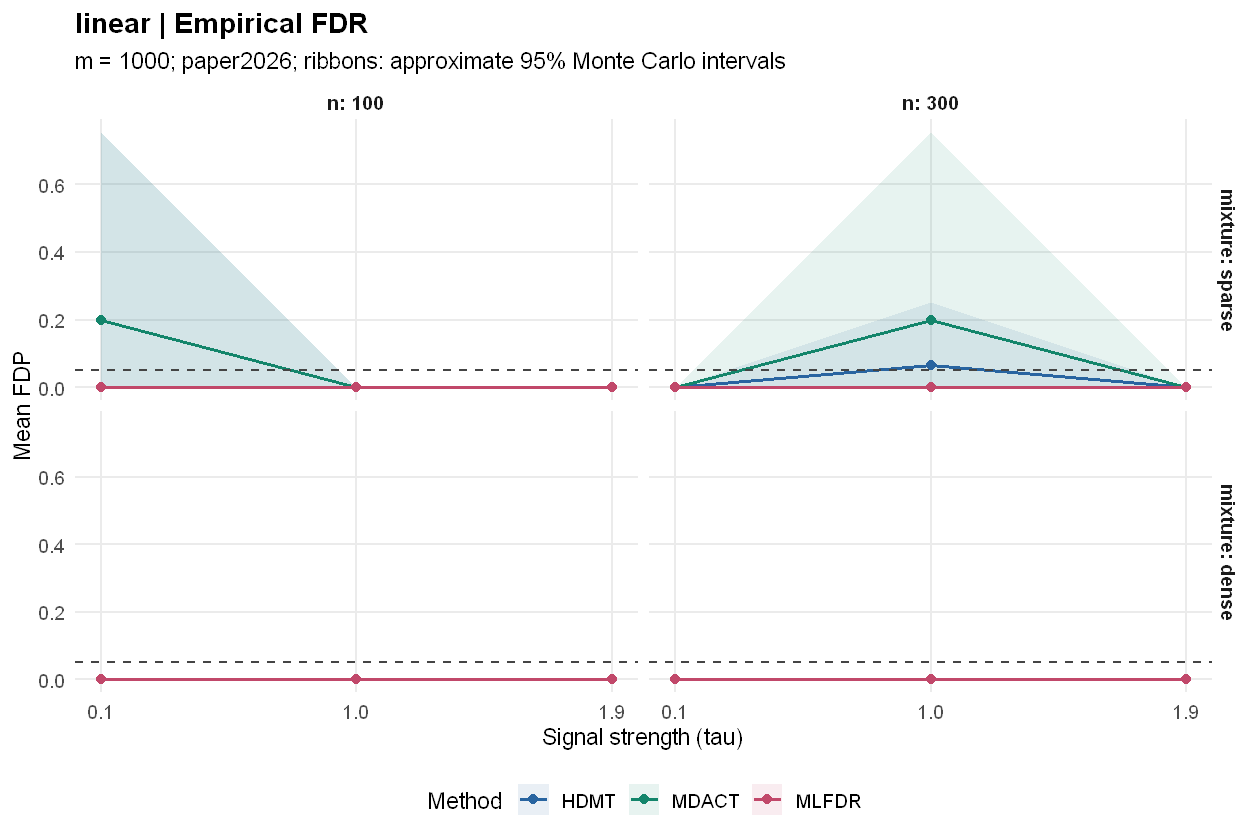

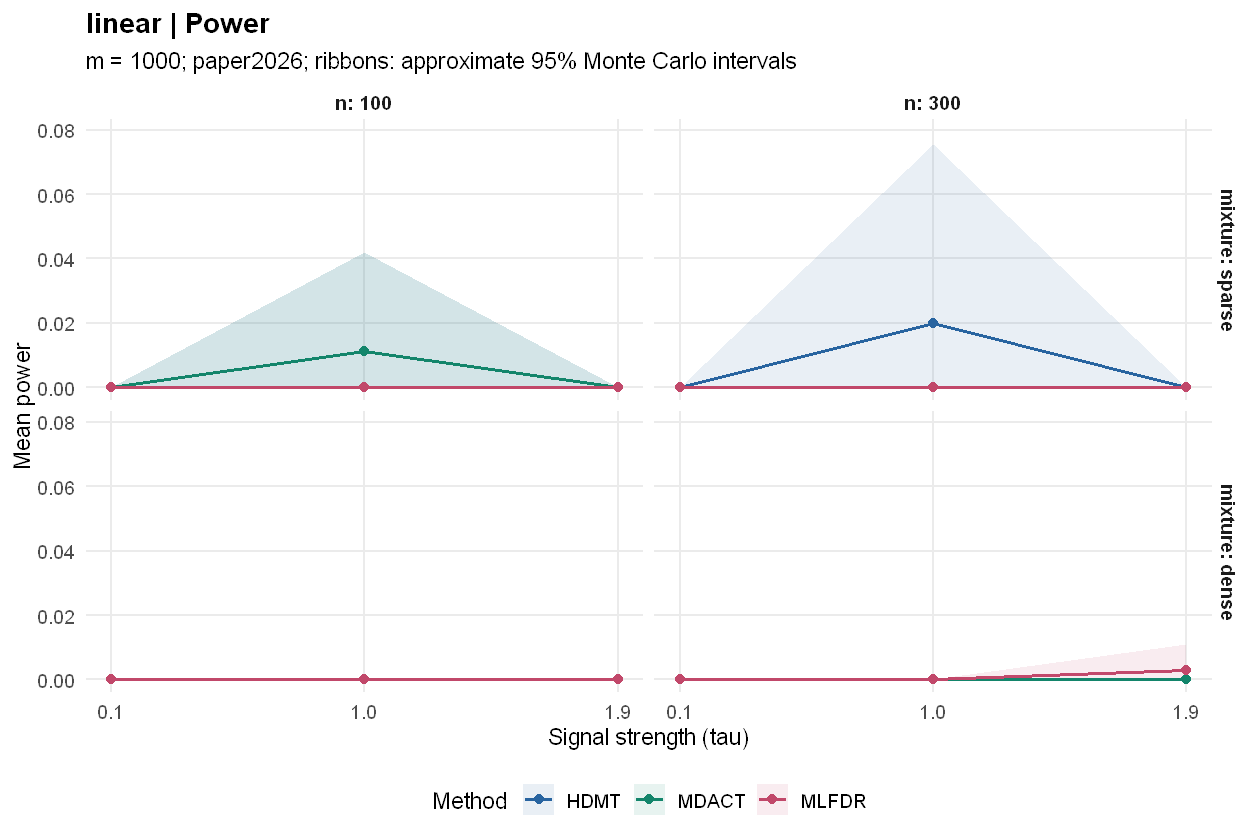

In [7]:
if ("linear" %in% config$scenarios) {
  print(plot_comparison(summary_table, "linear", "FDR"))
  print(plot_comparison(summary_table, "linear", "power"))
}

### 含已测混杂变量：对应论文图 3

列按样本量分面，行按稀疏/密集备择分面。这里是本实验实际输出，与原图的重复数、参数网格和实现细节不同。

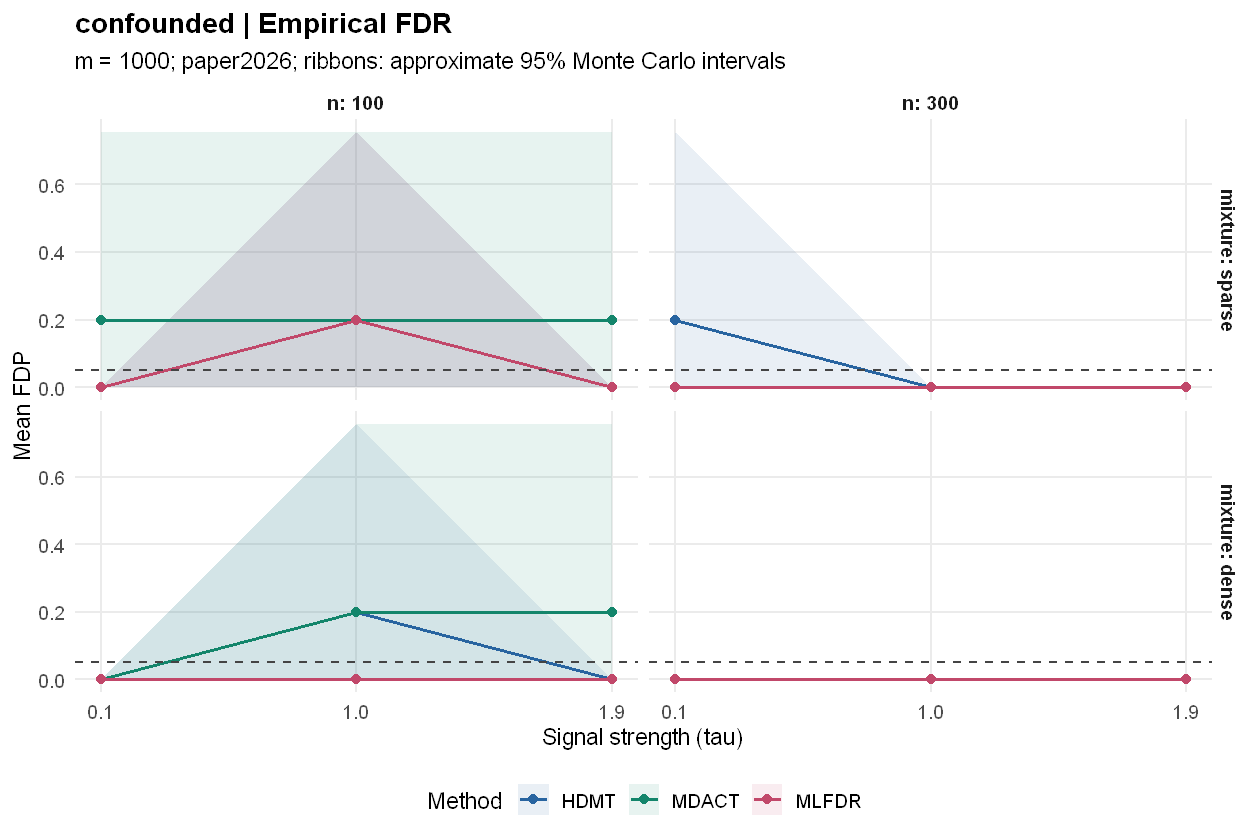

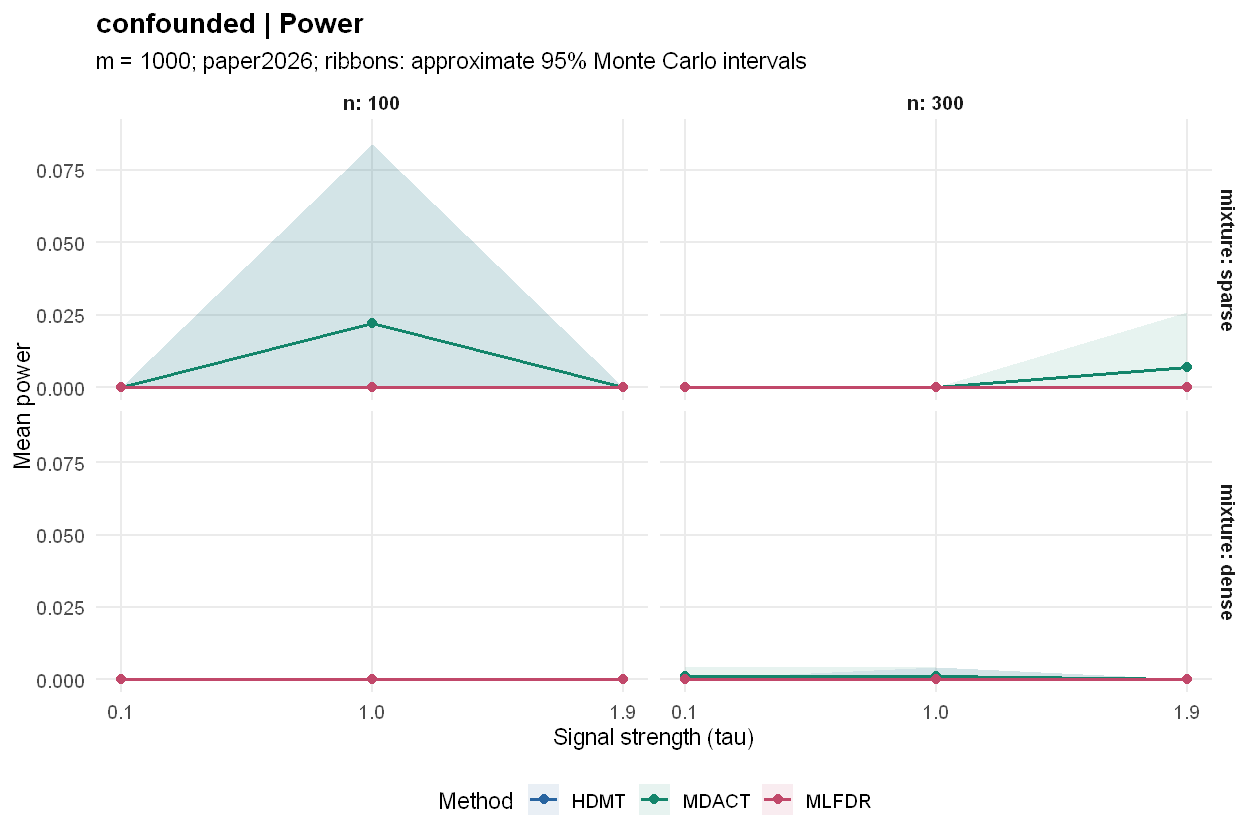

In [8]:
if ("confounded" %in% config$scenarios) {
  print(plot_comparison(summary_table, "confounded", "FDR"))
  print(plot_comparison(summary_table, "confounded", "power"))
}

### 二元结局：对应论文图 4

列按样本量分面，行按稀疏/密集备择分面。这里是本实验实际输出，与原图的重复数、参数网格和实现细节不同。

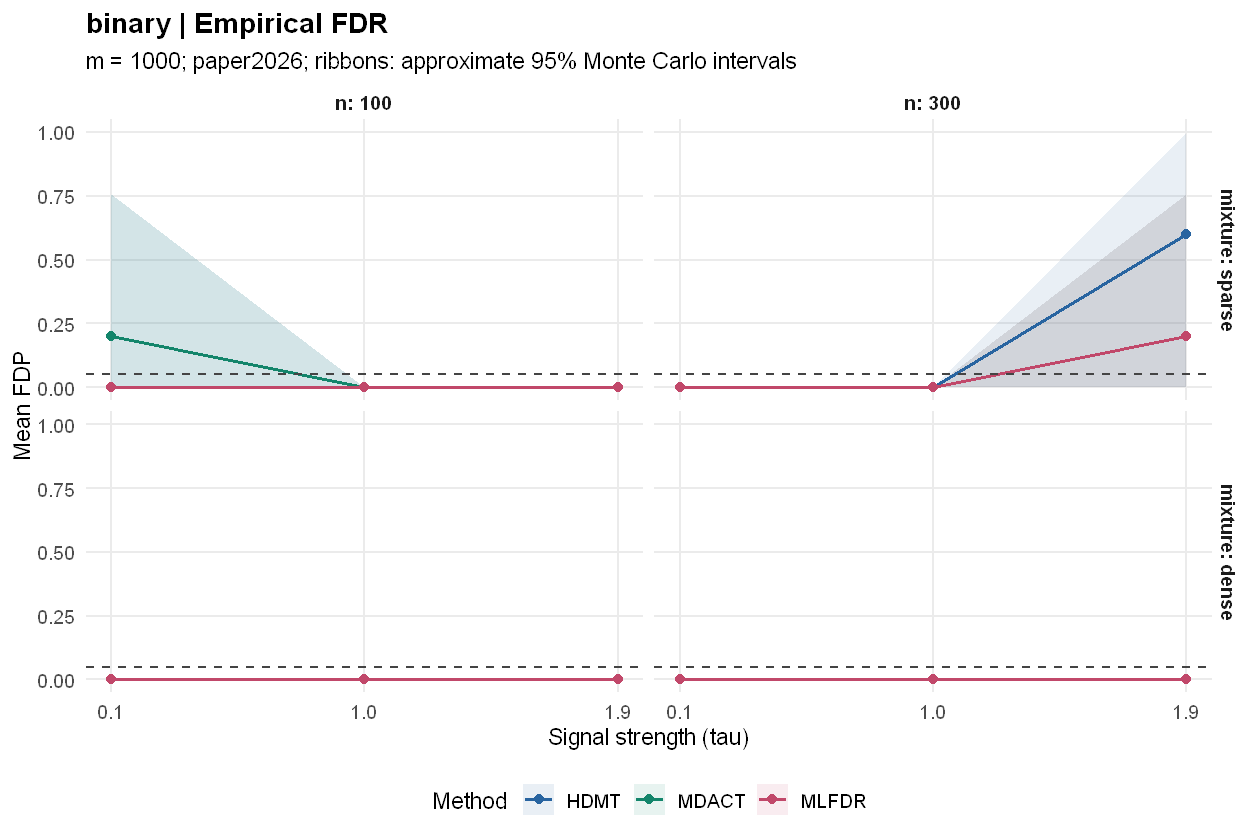

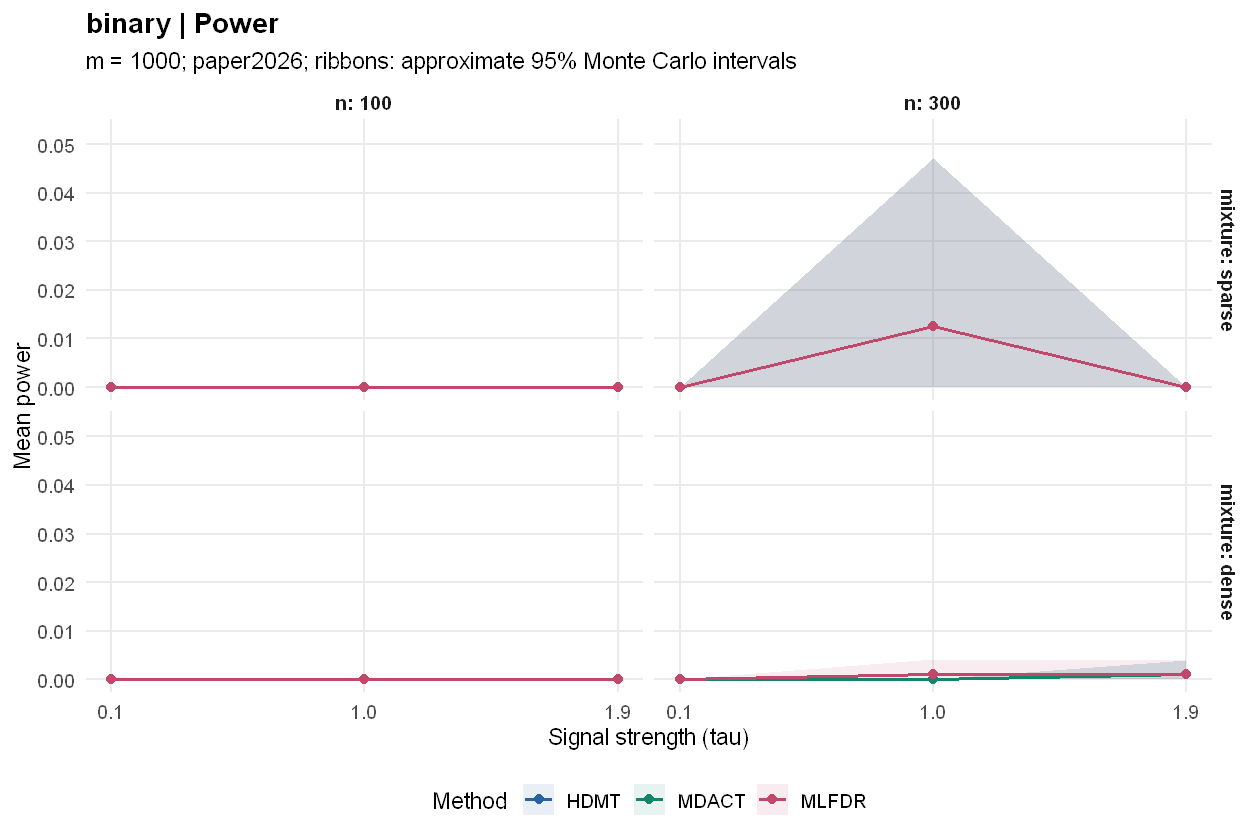

In [9]:
if ("binary" %in% config$scenarios) {
  print(plot_comparison(summary_table, "binary", "FDR"))
  print(plot_comparison(summary_table, "binary", "power"))
}

## 结果解读与复核

**本次默认演示不能用于方法优劣排名。** 初次交付的主实验 power 均值为 0–0.0222：它主要展示了弱信号下检出困难。原来的“功效最高”自动文字在功效全为零时也会选出一个方法，已经移除。三种方法都不拒绝时，经验 FDR=0、power=0；这不能作为有用的 FDR 控制证据。

为什么信号弱：在正文设定下，n=300、τ=1.9 的非零 α 均值仅为 0.095、标准差约为 0.0577。X~Bernoulli(0.1)、中介噪声标准差为1时，α 回归标准误约为 `1/sqrt(n*0.1*0.9)=0.192`。实际已保存数据中，真实 H11 路径的 β 几乎全部能通过单个 p<0.05，而 α 只有约 5%–13% 能通过。中介检验需要两段路径的证据，所以强 β 无法弥补弱 α。源码的非零 α 标准差为1、β 标准差为4，属于强度差别很大的另一种实验设定。

**FDR 偏高需要排查校准，不能只归因于5次重复。** 下方展开观测 FDR 均值最高的条件，显示逐次发现数和真假阳性。在初次交付的 binary/sparse/n300/τ1.9 条件，HDMT 的 FDP 为 `(1,1,1,0,0)`，均值0.6；它实际是3次各发现1个假阳性。复核发现，第2、3次估计 H01 比例仅为0.008和0.00625，实际分别为0.045和0.043，H10 比例也被估成0。只在诊断中换入真实零假设比例，这两次错误拒绝消失。真实比例不能作为正式比较的算法输入。

MLFDR 还存在参数范围不匹配：抽查的线性 n300 数据，其 α 先验方差搜索下界约0.032，真实生成方差为0.00333；源码设定的 β 生成方差为16，默认搜索上界为10。抽查中放宽范围能改善拟合似然，但没有改变拒绝数，因此这也不是“改一个参数即可恢复功效”的证据。上述诊断保存在 `docs/RESULTS_AUDIT.md` 与 `docs/audit/`，复核脚本为 `scripts/audit_results.R`；原结果和数据保留。

图中功效纵轴按数据放大，读数时应关注绝对数值。5次重复的 t 区间仅是描述性近似；5次全为零会得到零宽区间，**不表示真实 FDR 或功效已经被确定为零**。后面的源码对照每条件只有1次，只能读作单次 FDP 和 power。后续正式比较应明确选择正文设定或源码设定，增加重复，并检查拟合边界和混合比例稳定性。

In [10]:
cat("成功的 方法×重复：", sum(experiment$metrics$status == "ok"), "/", nrow(experiment$metrics), "\n")
cat("存在警告的 方法×重复：", sum(nzchar(experiment$metrics$warning)), "\n")
valid_fdr <- summary_table$FDR_mean[is.finite(summary_table$FDR_mean)]
if (length(valid_fdr)) cat(sprintf("各条件经验 FDR 均值范围：%.4f - %.4f（目标 %.2f）。\n", min(valid_fdr), max(valid_fdr), config$q))
# 展开观测均值最高的条件，仅作诊断，不据此进行显著性检验或排名。
valid <- summary_table[is.finite(summary_table$FDR_mean), ]
if (nrow(valid)) {
  worst <- valid[which.max(valid$FDR_mean), ]
  d <- experiment$metrics
  expanded <- d[d$scenario == worst$scenario & d$mixture == worst$mixture &
                  d$n == worst$n & d$tau == worst$tau & d$profile == worst$profile,
                c("scenario", "mixture", "n", "tau", "replicate", "method", "discoveries",
                  "false_discoveries", "true_discoveries", "FDP", "power")]
  cat("观测 FDR 均值最高条件的逐次结果（所有方法）：\n")
  IRdisplay::display(expanded)
}
cat("本演示用于检查流程、信号强度和校准问题，不支持稳定的方法排名或 FDR 保证。\n")

成功的 方法×重复： 540 / 540 


存在警告的 方法×重复： 142 


各条件经验 FDR 均值范围：0.0000 - 0.6000（目标 0.05）。


,scenario,mixture,n,tau,replicate,method,discoveries,false_discoveries,true_discoveries,FDP,power
,<chr>,<chr>,<int>,<dbl>,<int>,<chr>,<int>,<int>,<int>,<dbl>,<dbl>
97,binary,sparse,300,1.9,1,HDMT,1,1,0,1,0
98,binary,sparse,300,1.9,1,MDACT,1,1,0,1,0
99,binary,sparse,300,1.9,1,MLFDR,1,1,0,1,0
205,binary,sparse,300,1.9,2,HDMT,1,1,0,1,0
206,binary,sparse,300,1.9,2,MDACT,0,0,0,0,0
207,binary,sparse,300,1.9,2,MLFDR,0,0,0,0,0
313,binary,sparse,300,1.9,3,HDMT,1,1,0,1,0
314,binary,sparse,300,1.9,3,MDACT,0,0,0,0,0
315,binary,sparse,300,1.9,3,MLFDR,0,0,0,0,0


观测 FDR 均值最高条件的逐次结果（所有方法）：


本演示用于检查流程、信号强度和校准问题，不支持稳定的方法排名或 FDR 保证。


## 小规模源码设定对照

上述主实验严格使用发表版 simulation 正文的 `1/n`、`4/n` 噪声方差。它的效应通常比原仓库实际生成的效应弱；在这个演示中，power 很低也属于真实结果。

下面读取开头已经生成的另一批文件，按原作者代码的 **sd(α)=1、sd(β)=4，直接效应 mean=0.5、sd=1** 运行相同方法。只取 n 和 τ 的最大值、每场景/混合比例1次，默认6份数据。此表用于说明数据生成设定对结果的影响，不能据单次 FDP 断言 FDR 控制；也不与主实验重复数混合汇总。关闭首单元的 `RUN_SOURCE_CHECK` 可跳过。

In [11]:
if (RUN_SOURCE_CHECK) {
  source_manifest <- read_manifest(source_manifest_path)
  source_experiment <- run_experiment(source_manifest, source_check_config, PROJECT_ROOT, registry)
  source_table <- source_experiment$summary[, c("scenario", "mixture", "n", "tau", "method", "n_success", "n_error", "FDR_mean", "power_mean", "discoveries_mean")]
  names(source_table)[names(source_table) == "FDR_mean"] <- "single_FDP"
  names(source_table)[names(source_table) == "power_mean"] <- "single_power"
  IRdisplay::display(source_table)
  cat("源码设定对照结果：", source_experiment$output_dir, "\n")
}

Analysed 6/6 saved datasets; method errors: 0



scenario,mixture,n,tau,method,n_success,n_error,single_FDP,single_power,discoveries_mean
<chr>,<chr>,<int>,<dbl>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>
binary,dense,300,1.9,HDMT,1,0,0.05000000,0.6584158,140
binary,dense,300,1.9,MDACT,1,0,0.05594406,0.6683168,143
binary,dense,300,1.9,MLFDR,1,0,0.03472222,0.6881188,144
binary,sparse,300,1.9,HDMT,1,0,0.00000000,0.6956522,16
binary,sparse,300,1.9,MDACT,1,0,0.00000000,0.6956522,16
binary,sparse,300,1.9,MLFDR,1,0,0.00000000,0.7391304,17
confounded,dense,300,1.9,HDMT,1,0,0.02343750,0.6410256,128
confounded,dense,300,1.9,MDACT,1,0,0.02343750,0.6410256,128
confounded,dense,300,1.9,MLFDR,1,0,0.06250000,0.6923077,144


源码设定对照结果： D:/A_Mediation_analysis/code/mlfdr_simulation_lab/results/run_5580e7f5e7ad 


## 查看单次决策、诊断和原始评分

下面选取 τ 最大、n 最大的密集线性场景的一次重复，展示各方法发现数量和 MLFDR 的混合权重。决策表与模拟真值的拼接只发生在这里的评估阶段。

In [12]:
choices <- manifest$design
selected <- choices[choices$scenario == config$scenarios[1] & choices$mixture == names(config$mixtures)[length(config$mixtures)] &
                     choices$n == max(config$n) & choices$tau == max(config$tau) & choices$replicate == 1, ]
selected_id <- selected$case_id[1]
selected_data <- read_dataset(manifest, selected_id)
selected_results <- get_case_results(experiment, selected_id, PROJECT_ROOT)
decision_table <- selected_data$truth[, c("pathway_id", "state", "is_nonnull")]
for (method in names(selected_results)) {
  result <- selected_results[[method]]
  decision_table[[paste0("reject_", method)]] <- if (is.null(result)) NA else result$reject
}
write_csv(decision_table, file.path(experiment$output_dir, "example_decisions.csv"))
head(decision_table, 12)
if (!is.null(selected_results$MLFDR)) print(selected_results$MLFDR$diagnostics)
problem_rows <- experiment$diagnostics[nzchar(experiment$diagnostics$warning) | experiment$diagnostics$status == "error", ]
cat("有警告/错误的记录：", nrow(problem_rows), "；完整记录见 diagnostics.csv。\n")
head(problem_rows, 10)

,pathway_id,state,is_nonnull,reject_HDMT,reject_MDACT,reject_MLFDR
,<chr>,<chr>,<lgl>,<lgl>,<lgl>,<lgl>
1,pathway_0001,H00,FALSE,FALSE,FALSE,FALSE
2,pathway_0002,H01,FALSE,FALSE,FALSE,FALSE
3,pathway_0003,H11,TRUE,FALSE,FALSE,FALSE
4,pathway_0004,H10,FALSE,FALSE,FALSE,FALSE
5,pathway_0005,H11,TRUE,FALSE,FALSE,FALSE
6,pathway_0006,H01,FALSE,FALSE,FALSE,FALSE
7,pathway_0007,H01,FALSE,FALSE,FALSE,FALSE
8,pathway_0008,H10,FALSE,FALSE,FALSE,FALSE
9,pathway_0009,H01,FALSE,FALSE,FALSE,FALSE


$pi
  H_alpha H_beta       prob
1       0      0 0.51906674
2       1      0 0.07393326
3       0      1 0.34514925
4       1      1 0.06185075

$roundoff_clipped
[1] 0

$selected_mean_lfdr
[1] NA



有警告/错误的记录： 142 ；完整记录见 diagnostics.csv。


,case_id,method,status,warning,error,elapsed_seconds,cached
,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<lgl>
46,linear_dense_n100_t02_r0001,HDMT,ok,ties should not be present for the one-sample Kolmogorov-Smirnov test,,0.02,TRUE
47,linear_dense_n100_t02_r0001,MDACT,ok,ties should not be present for the one-sample Kolmogorov-Smirnov test,,0.03,TRUE
49,confounded_dense_n100_t02_r0001,HDMT,ok,ties should not be present for the one-sample Kolmogorov-Smirnov test,,0.04,TRUE
50,confounded_dense_n100_t02_r0001,MDACT,ok,ties should not be present for the one-sample Kolmogorov-Smirnov test,,0.05,TRUE
55,linear_sparse_n300_t02_r0001,HDMT,ok,ties should not be present for the one-sample Kolmogorov-Smirnov test,,0.03,TRUE
56,linear_sparse_n300_t02_r0001,MDACT,ok,ties should not be present for the one-sample Kolmogorov-Smirnov test,,0.03,TRUE
58,confounded_sparse_n300_t02_r0001,HDMT,ok,ties should not be present for the one-sample Kolmogorov-Smirnov test,,0.04,TRUE
59,confounded_sparse_n300_t02_r0001,MDACT,ok,ties should not be present for the one-sample Kolmogorov-Smirnov test,,0.05,TRUE
64,linear_dense_n300_t02_r0001,HDMT,ok,ties should not be present for the one-sample Kolmogorov-Smirnov test,,0.02,TRUE


## 新方法即插即用

已经提供一个可运行的插件 `R/methods/plugins/maxp_bh.R`，它按标准接口注册 `MaxP_BH`，默认不加入主比较。下面用已有的一份数据实际调用它，验证接入流程；**这不会重新生成数据**。要让它参与完整网格，把首单元的 `config$methods` 改成 `c("HDMT","MDACT","MLFDR","MaxP_BH")`，重新执行方法加载和实验单元即可。

接入你的新方法：

1. 复制 `examples/new_method_template.R` 到 `R/methods/plugins/my_method.R`。
2. 实现 `run(input, q, options)`，返回原顺序的 `logical(m)` 决策；可从 `input$raw` 获取原始观测。声明依赖包和独特方法名，不从文件/外部变量读取真值。
3. 在首单元追加方法名与 `config$method_options$MyMethod`；重新加载 registry 并运行实验。

修改插件文件会改变缓存指纹，原来的数据与其他不变方法继续复用。外部包参数变化、插件辅助文件或外部模型变化时需更新适配器 `version`。不要只改变函数名而保留旧方法标签。接口、测试和例子详见 `docs/ADDING_METHODS.md`。

In [13]:
# 实际验证一个新方法接口，复用已经读取的数据。
plugin_input <- make_method_input(selected_data, estimate_coefficients(selected_data)$estimates)
plugin_result <- registry$MaxP_BH$run(plugin_input, config$q, list())
invisible(validate_method_result(plugin_result, ncol(selected_data$M)))
data.frame(method = "MaxP_BH", as.data.frame(compute_metrics(plugin_result$reject, selected_data$truth)))

method,discoveries,false_discoveries,true_discoveries,alternatives,FDP,power
<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>
MaxP_BH,0,0,0,217,0,0


## 扩大实验与输出文件

演示已经执行并把结果保存在 notebook 中。开展正式比较时建议增加重复数，并关注 MCSE 与失败率。使用以下配置表达式替换首单元的控制区（不用单独修改每个底层脚本）：

```r
config <- default_config("paper_grid")
config$workers <- 2L
# 可先设 config$repetitions <- 20L，确认效果和耗时后再扩大。
```

对照原仓库实际数据生成代码：

```r
config <- default_config("source_demo")
# 此预设还自动设置 direct_mean=0.5、direct_sd=1。
```

| 文件位置 | 功能 |
|:--|:--|
| `data/data_<指纹>/manifest.csv`、`manifest.rds` | 每份数据的参数、种子、路径、MD5；重新读取入口 |
| `data/data_<指纹>/<case_id>.rds` | X、Z、M、Y、独立评估真值和生成参数 |
| `example_long.csv`、`example_long_truth.csv` | 第一份数据的跨语言示例长表和真值 |
| `data/estimates/` | 由文件内容与拟合代码指纹控制的回归缓存 |
| `results/run_<指纹>/summary.csv` | 经验 FDR / power 均值、SD、MCSE、区间、有效重复数 |
| `replicate_metrics.csv`、`diagnostics.csv` | 单次指标、成功/失败/警告、方法耗时；耗时不含共享回归与读盘 |
| `figures/`、`example_decisions.csv` | 六张可分享 PNG 与一次实验的逐路径决策 |
| `config.R`、`config.rds`、`methods.csv`、`package_versions.csv`、`sessionInfo.txt`、`provenance.rds` | 配置、方法说明和环境/代码来源记录 |
| `results/method_cache/` | 每方法决策、可选评分与诊断；不将失败当作有效结果缓存 |

`README.md` 有启动步骤；`tests/run_tests.R` 检查生成、OLS 等价性、step-up 边界和所有适配器。项目不依赖原仓库的绝对路径，也不清理用户工作区。重启内核后从首单元顺序执行即可；已有数据与结果通常会直接校验/复用。

In [14]:
cat("PROJECT_ROOT =", PROJECT_ROOT, "\n")
cat("数据入口 =", manifest_path, "\n")
cat("本次结果 =", experiment$output_dir, "\n")
list.files(experiment$output_dir)
sessionInfo()

PROJECT_ROOT = D:/A_Mediation_analysis/code/mlfdr_simulation_lab 


数据入口 = D:/A_Mediation_analysis/code/mlfdr_simulation_lab/data/data_6fdb451c6d0d/manifest.rds 


本次结果 = D:/A_Mediation_analysis/code/mlfdr_simulation_lab/results/run_45a379a50352 


[1] "config.R"              "config.rds"            "diagnostics.csv"      
 [4] "example_decisions.csv" "experiment.rds"        "figures"              
 [7] "methods.csv"           "package_versions.csv"  "provenance.rds"       
[10] "replicate_metrics.csv" "sessionInfo.txt"       "summary.csv"

R version 4.6.1 (2026-06-24 ucrt)
Platform: x86_64-w64-mingw32/x64
Running under: Windows 11 x64 (build 26200)

Matrix products: default
  LAPACK version 3.12.1

locale:
[1] LC_COLLATE=Chinese (Simplified)_China.utf8 
[2] LC_CTYPE=Chinese (Simplified)_China.utf8   
[3] LC_MONETARY=Chinese (Simplified)_China.utf8
[4] LC_NUMERIC=C                               
[5] LC_TIME=Chinese (Simplified)_China.utf8    

time zone: Asia/Shanghai
tzcode source: internal

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

loaded via a namespace (and not attached):
 [1] gtable_0.3.6       jsonlite_2.0.0     dplyr_1.2.1        compiler_4.6.1    
 [5] crayon_1.5.3       tidyselect_1.2.1   Rcpp_1.1.2         IRdisplay_1.1     
 [9] stringr_1.6.0      parallel_4.6.1     splines_4.6.1      systemfonts_1.3.2 
[13] scales_1.4.0       textshaping_1.0.5  uuid_1.2-2         fastmap_1.2.0     
[17] IRkernel_1.3.2     MLFDR_0.1.0        plyr_1.8.9         ggplot2_4.0